In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from experiment_configs import get_experiment_dict
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors

In [2]:
class ExperimentWindowEvaluator:
    def __init__(self, outdir, experiments_dict, varnames, windows,
                 landmask, metric='TCC', percentile=0.9, nens_key='nens',
                 fig_outdir=None, normalize_to=None):
        self.outdir = outdir
        self.experiments_dict = experiments_dict
        self.varnames = varnames
        self.windows = windows
        self.landmask = landmask
        self.metric = metric
        self.percentile = percentile
        self.nens_key = nens_key
        self.normalize_to = normalize_to
        self.fig_outdir = fig_outdir or os.path.join(outdir, "experiment_heatmaps")
        os.makedirs(self.fig_outdir, exist_ok=True)

    def plot_across_experiments_by_window(self, summary_file_dict, metric, percentile,
                                          region='global', cmap='coolwarm', vmin=None, vmax=None,
                                          fontz=10, n_color_bins=5):
        df_dict = {win_label: pd.DataFrame(columns=self.varnames.keys()) for win_label in self.windows}

        for exp_name, nc_path in summary_file_dict.items():
            ds = xr.open_dataset(nc_path)
            var_key = f"{metric}_p{int(percentile * 100)}"
            if var_key not in ds:
                print(f"[WARNING] {var_key} not found in {nc_path}")
                continue
            da = ds[var_key]
                
            df = da.to_pandas()

            for win_label in df.index:
                df_dict[win_label].loc[exp_name] = df.loc[win_label]

        for idx, (win_label, df) in enumerate(df_dict.items()):
            df = df.astype(float)
            nrows, ncols = df.shape
            fig_width = ncols * 0.8 + 3
            fig_height = nrows * 0.5 + 3

            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="1.5%", pad=0.1)

            # Setup discrete colormap
            levels = np.linspace(vmin, vmax, n_color_bins + 1)
            cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)
            norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_discrete.N)

            heatmap = sns.heatmap(
                df, annot=True, fmt=".2f", cmap=cmap_discrete,
                norm=norm,
                cbar=False,
                ax=ax,
                annot_kws={"size": fontz},
                linewidths=0.5,
                linecolor='gray'
            )

            sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cax, boundaries=levels, ticks=levels)
            cbar.set_label(metric, fontsize=fontz, rotation=270, labelpad=15)
            cbar.ax.tick_params(labelsize=fontz - 1)

            letter = "" #f"({chr(97 + idx)})"
            ax.set_title(
                f"{letter} {metric} {int(percentile * 100)}th Percentile - {region.capitalize()} - {win_label}",
                fontsize=fontz * 1.5
            )
            ax.set_ylabel("", fontsize=fontz)
            ax.set_xlabel("Variable", fontsize=fontz)
            ax.tick_params(axis='x', labelrotation=45, labelsize=fontz)
            ax.tick_params(axis='y', labelrotation=0, labelsize=fontz)

            out_base = f"{metric}_p{int(percentile * 100)}_{region}_{win_label}"
            png_path = os.path.join(self.fig_outdir, f"{out_base}.pdf")
            csv_path = os.path.join(self.fig_outdir, f"{out_base}.csv")

            fig.tight_layout()
            fig.savefig(png_path, dpi=600)
            plt.show()
            df.to_csv(csv_path)

            print(f"[SAVED] {png_path}")
            print(f"[SAVED] {csv_path}")
            plt.close(fig)


In [3]:
class ExperimentWindowEvaluator:
    def __init__(self, outdir, experiments_dict, varnames, windows,
                 landmask, metric='TCC', percentile=0.9, nens_key='nens',
                 fig_outdir=None, normalize_to=None):
        self.outdir = outdir
        self.experiments_dict = experiments_dict
        self.varnames = varnames
        self.windows = windows
        self.landmask = landmask
        self.metric = metric
        self.percentile = percentile
        self.nens_key = nens_key
        self.normalize_to = normalize_to
        self.fig_outdir = fig_outdir or os.path.join(outdir, "experiment_heatmaps")
        os.makedirs(self.fig_outdir, exist_ok=True)

    def plot_across_experiments_by_window(self, summary_file_dict, metric, percentile,
                                          region='global', cmap='coolwarm', vmin=None, vmax=None,
                                          fontz=10, n_color_bins=5):
        df_dict = {win_label: pd.DataFrame(columns=self.varnames.keys()) for win_label in self.windows}
    
        var_key = f"{metric}_p{int(percentile * 100)}"
        ref_values = {}
    
        # Step 1: Load reference values if RMSE normalization is requested
        if metric == "RMSE" and self.normalize_to:
            ref_path = summary_file_dict.get(self.normalize_to)
            if ref_path is None:
                print(f"[WARNING] Reference experiment '{self.normalize_to}' not found in summary_file_dict.")
            else:
                ds_ref = xr.open_dataset(ref_path)
                if var_key in ds_ref:
                    ref_df = ds_ref[var_key].to_pandas()
                    ref_values = ref_df.to_dict(orient='index')  # {win_label: {varname: value}}
    
        # Step 2: Load data for each experiment and normalize if needed
        for exp_name, nc_path in summary_file_dict.items():
            ds = xr.open_dataset(nc_path)
            if var_key not in ds:
                print(f"[WARNING] {var_key} not found in {nc_path}")
                continue
    
            da = ds[var_key]
            df = da.to_pandas()
    
            # Normalize RMSE values if reference is provided
            if metric == "RMSE" and self.normalize_to and ref_values:
                for win_label in df.index:
                    for var in df.columns:
                        ref_val = ref_values.get(win_label, {}).get(var, np.nan)
                        model_val = df.loc[win_label, var]
                        if np.isfinite(ref_val) and np.isfinite(model_val):
                            df.loc[win_label, var] = (model_val - ref_val) / (model_val + ref_val)
                        else:
                            df.loc[win_label, var] = np.nan
    
            # Accumulate into df_dict
            for win_label in df.index:
                df_dict[win_label].loc[exp_name] = df.loc[win_label]
    
        # Step 3: Plot for each window
        for idx, (win_label, df) in enumerate(df_dict.items()):
            df = df.astype(float)
            nrows, ncols = df.shape
            fig_width = ncols * 0.8 + 3
            fig_height = nrows * 0.5 + 3
    
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="1.5%", pad=0.1)
    
            # Setup discrete colormap
            levels = np.linspace(vmin, vmax, n_color_bins + 1)
            cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)
            norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_discrete.N)
    
            sns.heatmap(
                df, annot=True, fmt=".2f", cmap=cmap_discrete,
                norm=norm,
                cbar=False,
                ax=ax,
                annot_kws={"size": fontz},
                linewidths=0.5,
                linecolor='gray'
            )
    
            sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cax, boundaries=levels, ticks=levels)
            cbar.set_label(metric, fontsize=fontz, rotation=270, labelpad=15)
            cbar.ax.tick_params(labelsize=fontz - 1)
    
            title_suffix = f" (Normalized to {self.normalize_to})" if metric == "RMSE" and self.normalize_to else ""
            ax.set_title(
                f"{metric} {int(percentile * 100)}th Percentile - {region.capitalize()} - {win_label}{title_suffix}",
                fontsize=fontz * 1.5
            )
            ax.set_ylabel("", fontsize=fontz)
            ax.set_xlabel("Variable", fontsize=fontz)
            ax.tick_params(axis='x', labelrotation=45, labelsize=fontz)
            ax.tick_params(axis='y', labelrotation=0, labelsize=fontz)
    
            # Save
            suffix = f"_normto_{self.normalize_to}" if metric == "RMSE" and self.normalize_to else ""
            out_base = f"{metric}_p{int(percentile * 100)}_{region}_{win_label}{suffix}"
            png_path = os.path.join(self.fig_outdir, f"{out_base}.pdf")
            csv_path = os.path.join(self.fig_outdir, f"{out_base}.csv")
    
            fig.tight_layout()
            fig.savefig(png_path, dpi=600)
            plt.show()
            df.to_csv(csv_path)
    
            print(f"[SAVED] {png_path}")
            print(f"[SAVED] {csv_path}")
            plt.close(fig)


In [7]:
class ExperimentWindowEvaluator:
    def __init__(self, outdir, experiments_dict, varnames, windows,
                 landmask, metric='TCC', percentile=0.9, nens_key='nens',
                 fig_outdir=None):
        self.outdir = outdir
        self.experiments_dict = experiments_dict
        self.varnames = varnames
        self.windows = windows
        self.landmask = landmask
        self.metric = metric
        self.percentile = percentile
        self.nens_key = nens_key
        self.fig_outdir = fig_outdir or os.path.join(outdir, "experiment_heatmaps")
        os.makedirs(self.fig_outdir, exist_ok=True)

    def plot_across_experiments_by_window(self, summary_file_dict, metric, percentile,
                                          region='global', cmap='coolwarm', vmin=None, vmax=None,
                                          fontz=10, n_color_bins=5):
        df_dict = {win_label: pd.DataFrame(columns=self.varnames.keys()) for win_label in self.windows}
        var_key = f"{metric}_p{int(percentile * 100)}"

        # Step 1: Load data from all experiments
        for exp_name, nc_path in summary_file_dict.items():
            ds = xr.open_dataset(nc_path)
            if var_key not in ds:
                print(f"[WARNING] {var_key} not found in {nc_path}")
                continue
            da = ds[var_key]
            df = da.to_pandas()

            for win_label in df.index:
                df_dict[win_label].loc[exp_name] = df.loc[win_label]

        # Step 2: Normalize RMSE using mean across experiments (if needed)
        if metric == "RMSE":
            for win_label, df in df_dict.items():
                df = df.astype(float)
                mean_vals = df.mean(axis=0, skipna=True)  # mean per variable
                for exp_name in df.index:
                    for var in df.columns:
                        val = df.loc[exp_name, var]
                        ref_val = mean_vals[var]
                        if np.isfinite(val) and np.isfinite(ref_val) and ref_val > 1e-8:
                            df.loc[exp_name, var] = (val - ref_val) / (val + ref_val)
                        else:
                            df.loc[exp_name, var] = np.nan
                df_dict[win_label] = df  # update with normalized values

        # Step 3: Plot heatmaps
        for idx, (win_label, df) in enumerate(df_dict.items()):
            df = df.astype(float)
            nrows, ncols = df.shape
            fig_width = ncols * 0.8 + 3
            fig_height = nrows * 0.5 + 3

            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="1.5%", pad=0.1)

            levels = np.linspace(vmin, vmax, n_color_bins + 1)
            cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)
            norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_discrete.N)

            sns.heatmap(
                df, annot=True, fmt=".2f", cmap=cmap_discrete,
                norm=norm,
                cbar=False,
                ax=ax,
                annot_kws={"size": fontz},
                linewidths=0.5,
                linecolor='gray'
            )

            sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cax, boundaries=levels, ticks=levels)
            cbar.set_label(metric, fontsize=fontz, rotation=270, labelpad=15)
            cbar.ax.tick_params(labelsize=fontz - 1)

            title_suffix = " (Normalized to Mean of All Experiments)" if metric == "RMSE" else ""
            ax.set_title(
                f"{metric} {int(percentile * 100)}th Percentile - {region.capitalize()} - {win_label}{title_suffix}",
                fontsize=fontz * 1.5
            )
            ax.set_ylabel("", fontsize=fontz)
            ax.set_xlabel("Variable", fontsize=fontz)
            ax.tick_params(axis='x', labelrotation=45, labelsize=fontz)
            ax.tick_params(axis='y', labelrotation=0, labelsize=fontz)

            suffix = "_norm_to_mean" if metric == "RMSE" else ""
            out_base = f"{metric}_p{int(percentile * 100)}_{region}_{win_label}{suffix}"
            png_path = os.path.join(self.fig_outdir, f"{out_base}.pdf")
            csv_path = os.path.join(self.fig_outdir, f"{out_base}.csv")

            fig.tight_layout()
            fig.savefig(png_path, dpi=600)
            plt.show()
            df.to_csv(csv_path)

            print(f"[SAVED] {png_path}")
            print(f"[SAVED] {csv_path}")
            plt.close(fig)


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


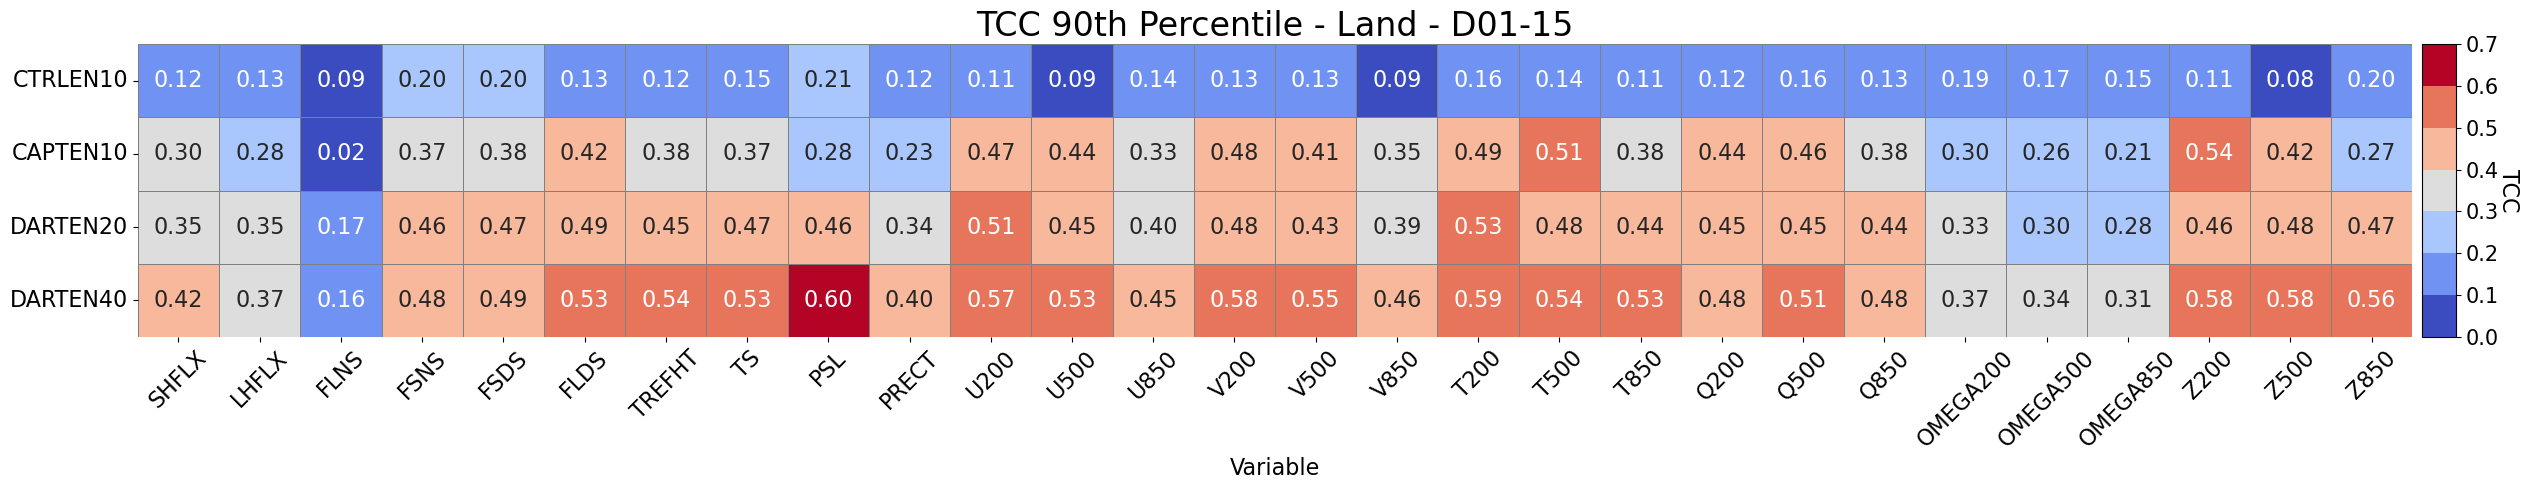

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D01-15.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D01-15.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


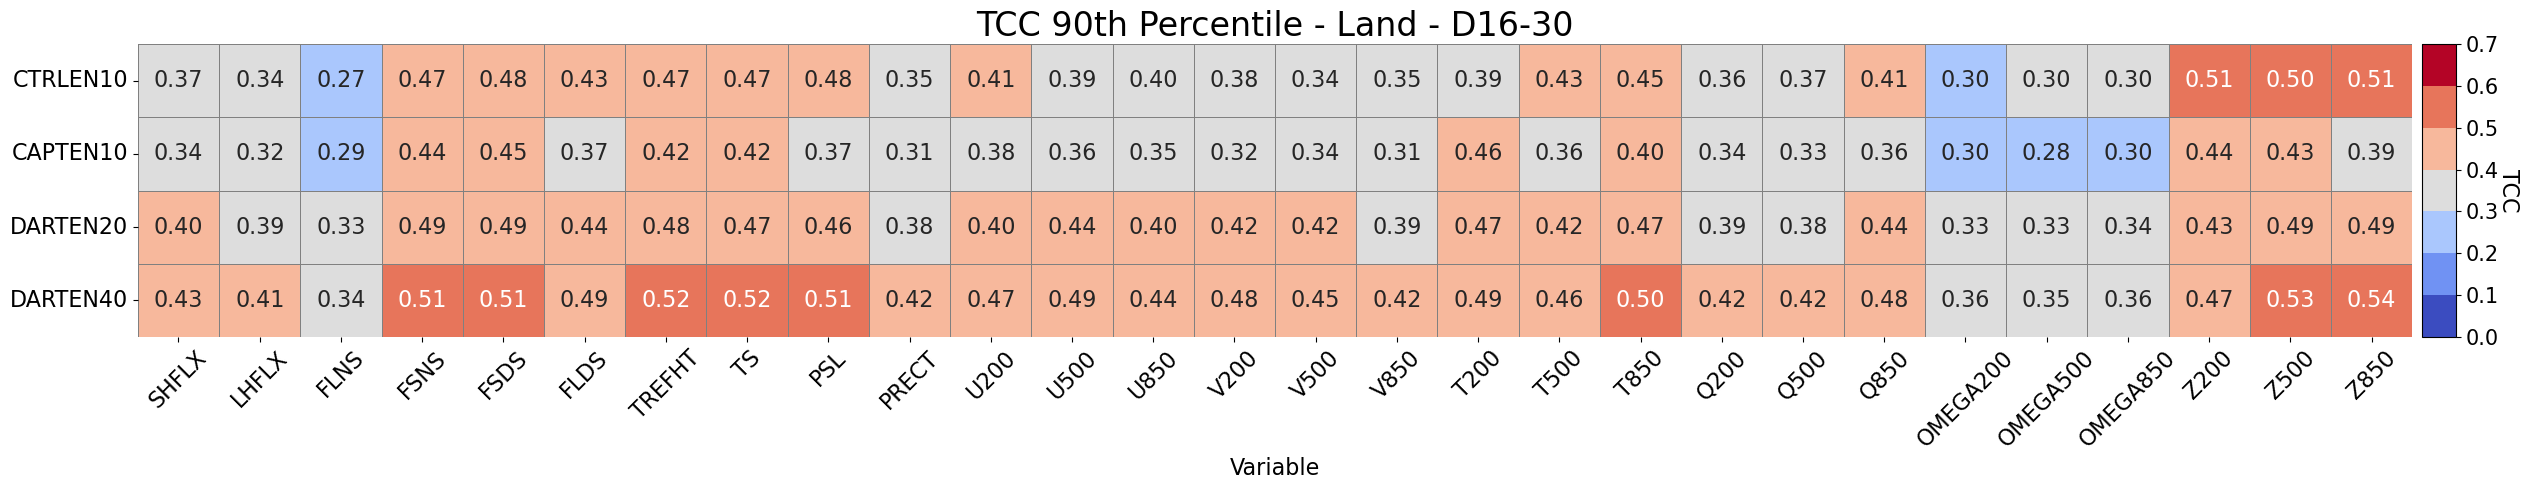

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D16-30.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D16-30.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


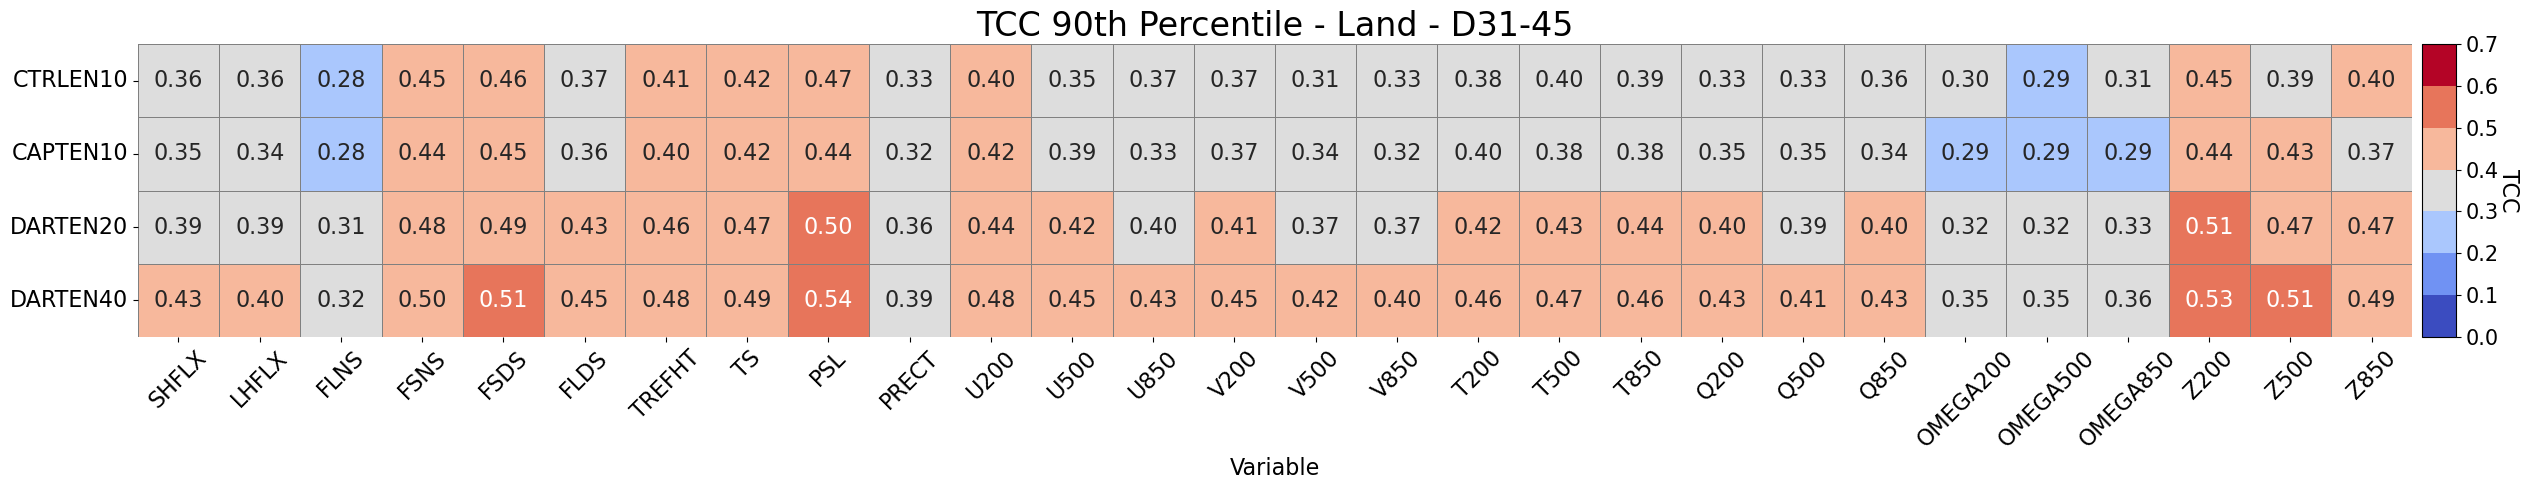

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D31-45.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D31-45.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


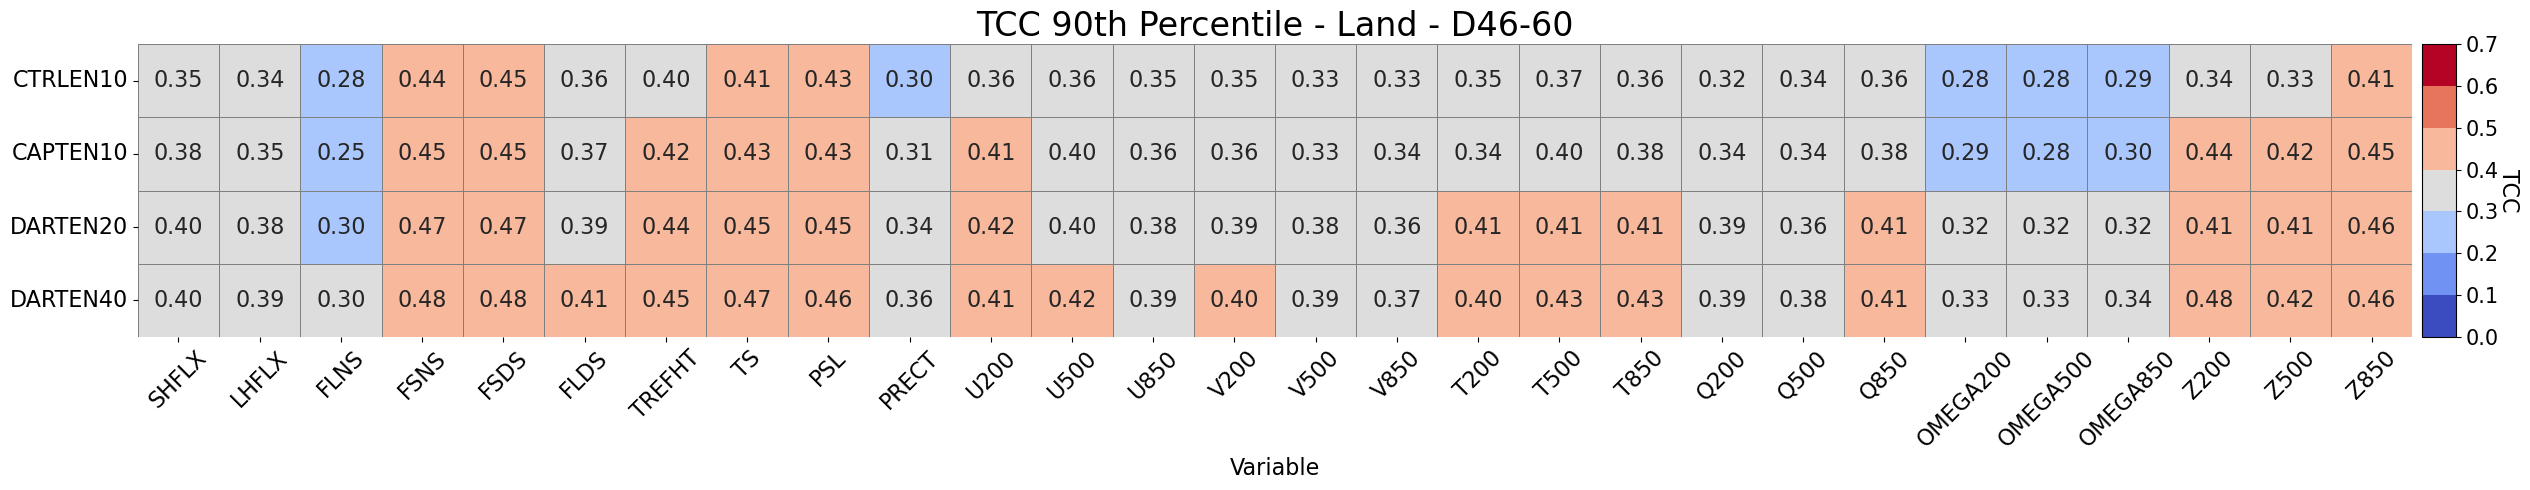

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D46-60.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/TCC_p90_land_D46-60.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


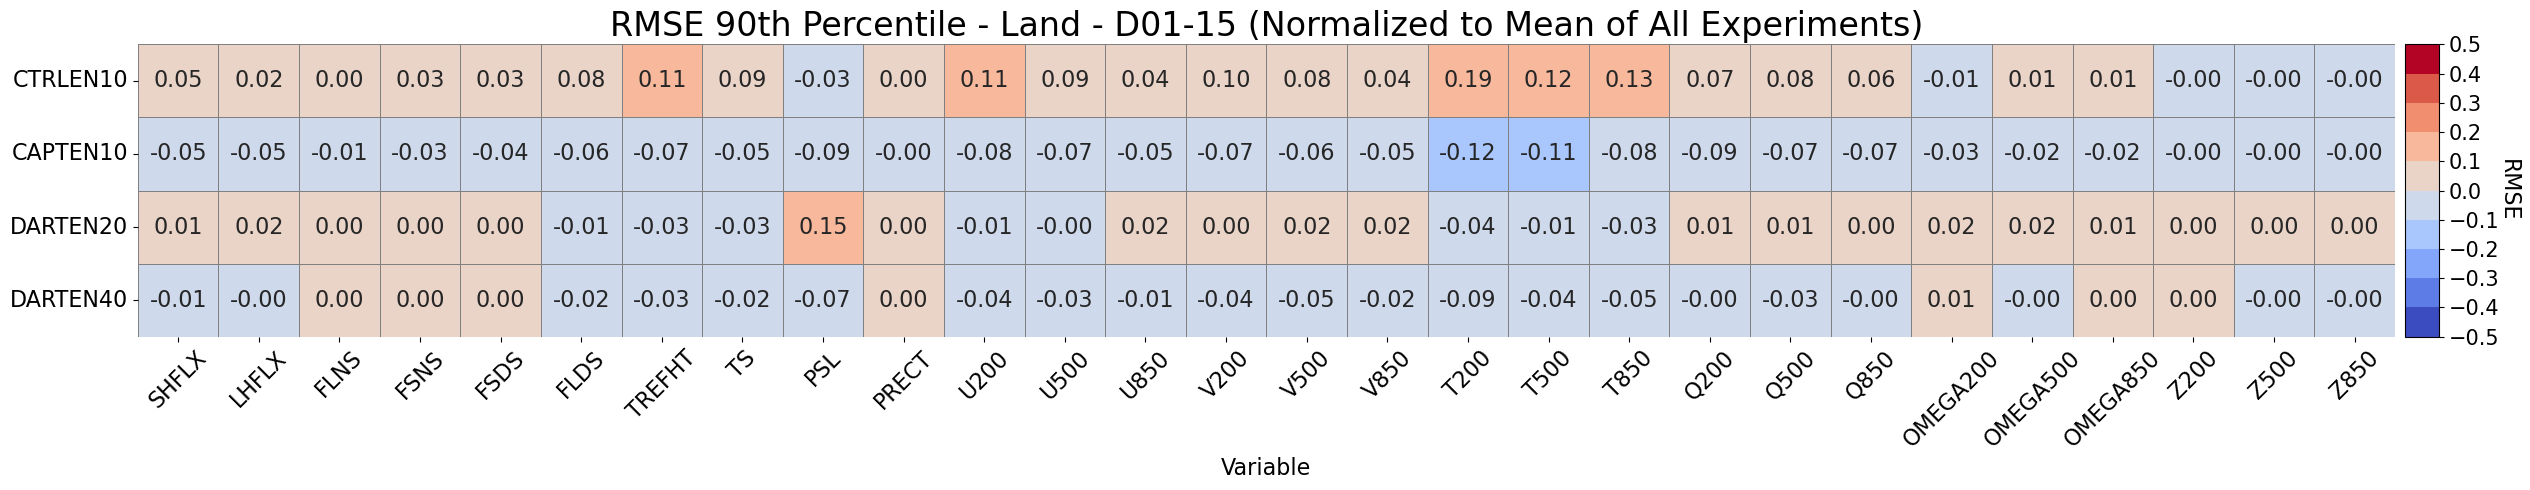

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D01-15_norm_to_mean.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D01-15_norm_to_mean.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


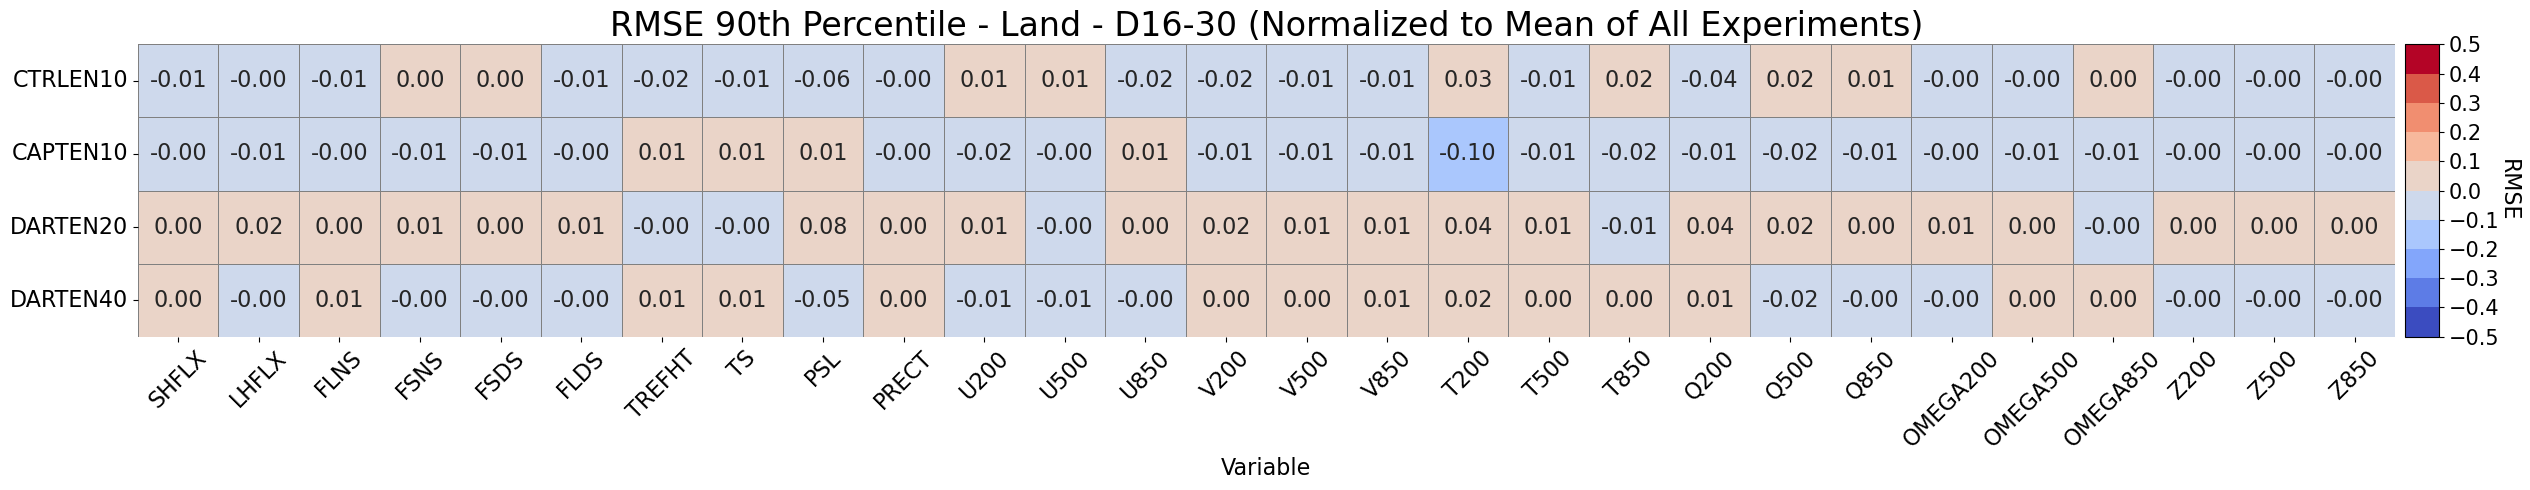

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D16-30_norm_to_mean.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D16-30_norm_to_mean.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


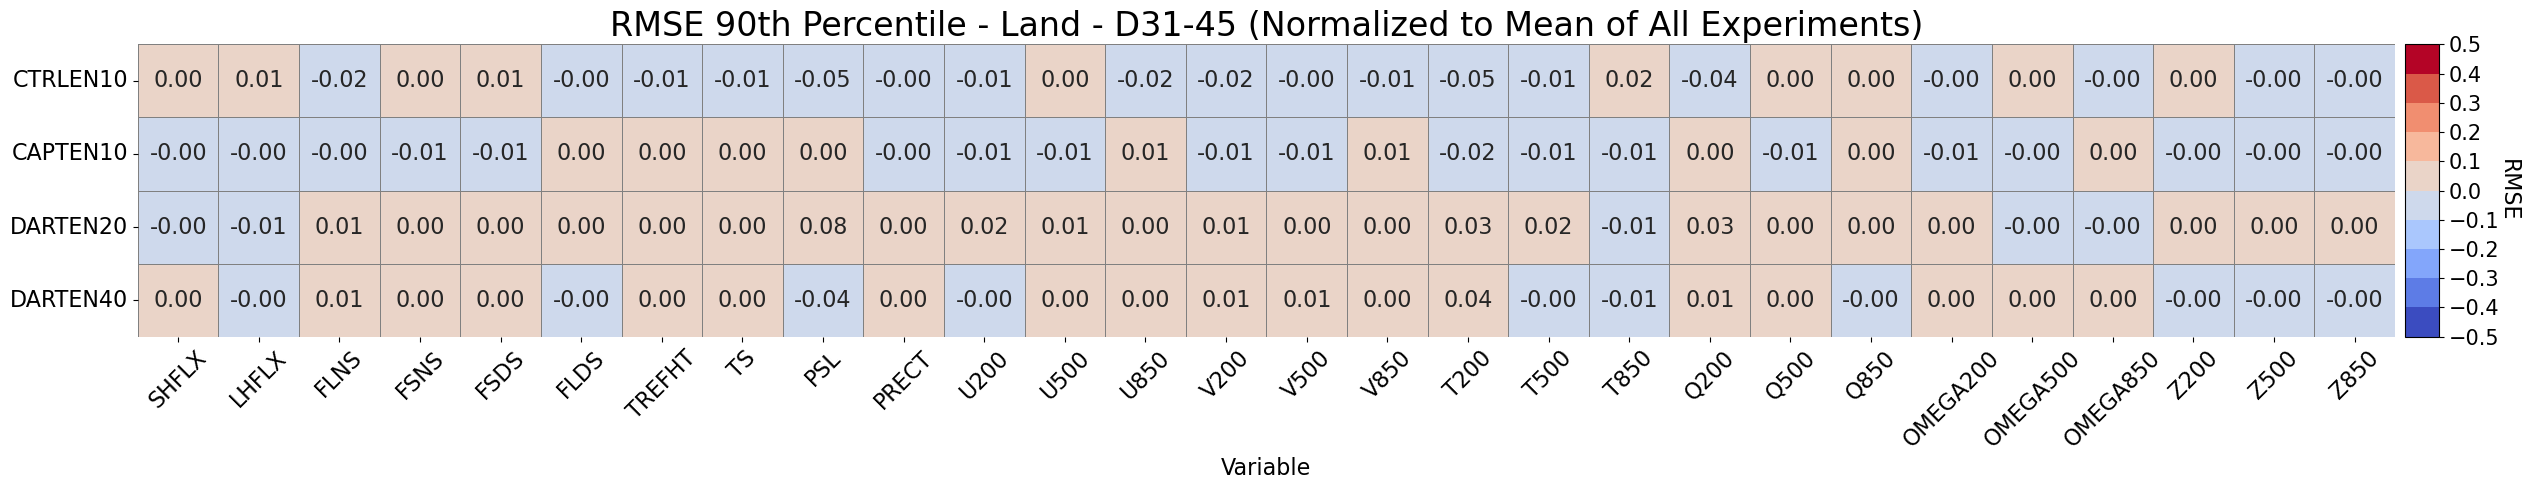

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D31-45_norm_to_mean.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D31-45_norm_to_mean.csv


/tmp/ipykernel_1451072/2677737150.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_discrete = plt.cm.get_cmap(cmap, n_color_bins)


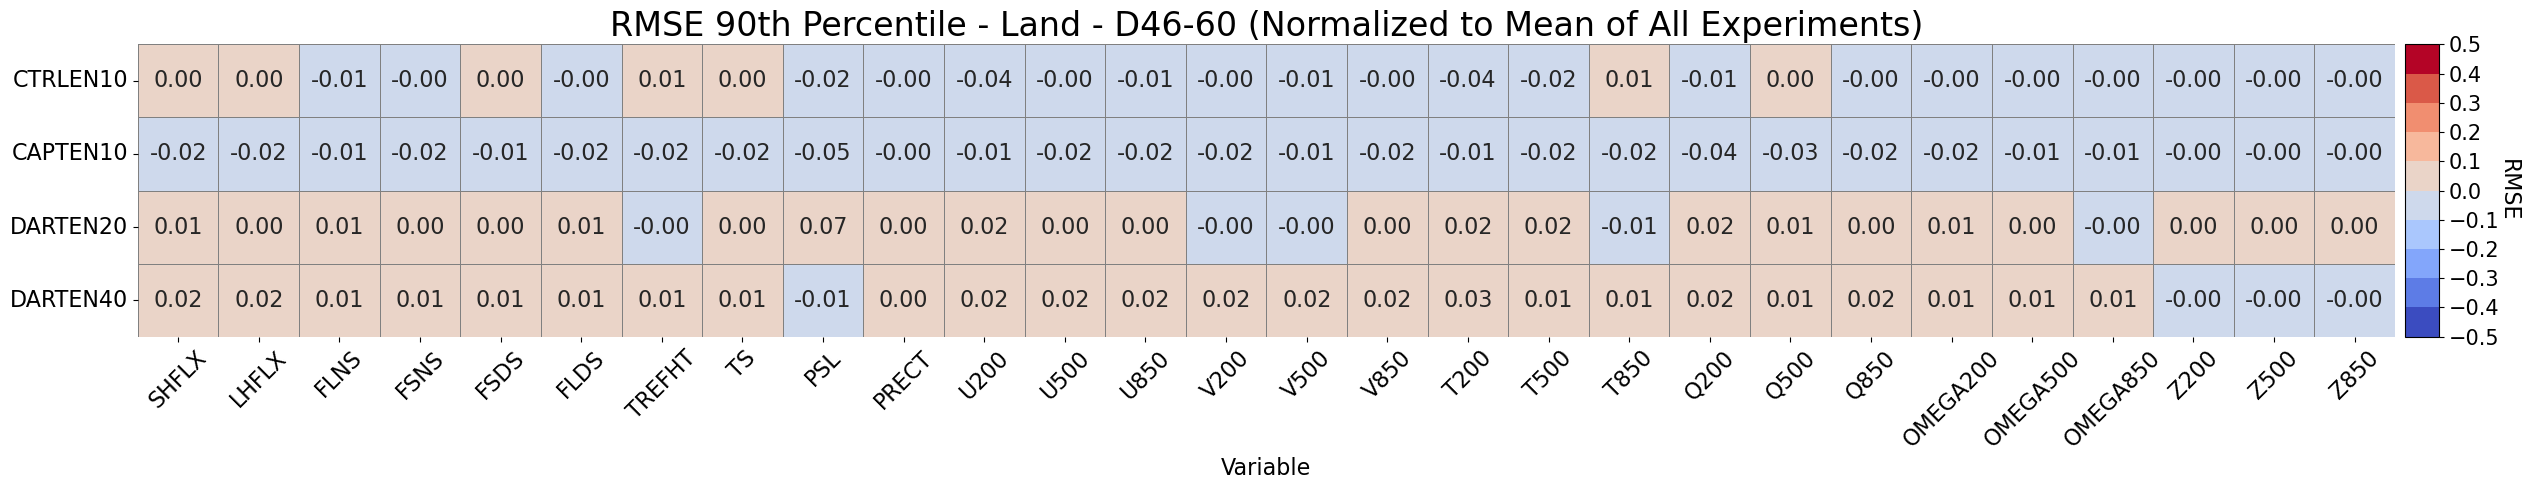

[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D46-60_norm_to_mean.pdf
[SAVED] /global/homes/z/zhan391/analysis/diagnostic/figures/RMSE_p90_land_D46-60_norm_to_mean.csv


In [9]:
if __name__ == "__main__":
    top_path = "/pscratch/sd/z/zhan391/e3sm_dart"
    out_path = os.path.join(top_path, "diag_dart")
    summary_dir = os.path.join(out_path, "summary_metrics_netcdf")
    fig_path = "/global/homes/z/zhan391/analysis/diagnostic/figures"

    landmask_file = os.path.join(out_path, "landmask_1x1.nc")
    landmask = xr.open_dataset(landmask_file)['landfrac']
    if landmask.lon.max() > 180:
        landmask['lon'] = ((landmask['lon'] + 180) % 360) - 180
        landmask = landmask.sortby('lon')

    windows = {
        "D01-15": ("2012-01-01", "2012-01-15"),
        "D16-30": ("2012-01-16", "2012-01-30"),
        "D31-45": ("2012-01-31", "2012-02-14"),
        "D46-60": ("2012-02-15", "2012-03-01"),
    }

    varnames = {
        'SHFLX': "W/m2", 'LHFLX': "W/m2", 'FLNS': "W/m2", 'FSNS': "W/m2", 'FSDS': "W/m2", 'FLDS': "W/m2",
        'TREFHT': 'K', 'TS': 'K', 'PSL': 'Pa', 'PRECT': 'm/s',
        'U200': 'm/s', 'U500': 'm/s', 'U850': 'm/s',
        'V200': 'm/s', 'V500': 'm/s', 'V850': 'm/s',
        'T200': 'K', 'T500': 'K', 'T850': 'K',
        'Q200': 'kg/kg', 'Q500': 'kg/kg', 'Q850': 'kg/kg',
        'OMEGA200': 'Pa/s', 'OMEGA500': 'Pa/s', 'OMEGA850': 'Pa/s',
        'Z200': 'm2/s2', 'Z500': 'm2/s2', 'Z850': 'm2/s2'
    }

    region = "land" #"global"
    percentile = 0.9 
    
    exp_dict = get_experiment_dict('v3_hindcast')  # includes nens per experiment
    summary_file_dict = {
        exp_name: os.path.join(summary_dir, f"tcc_rmse_metrics_allpct_{region}_{exp_name}.nc")
        for exp_name in exp_dict
    }

    for metric in ['TCC', 'RMSE']:
        cmap = 'coolwarm' if metric == 'TCC' else 'coolwarm' #'viridis'
        if metric == 'TCC':
            vmin, vmax = (0.0, 0.7) 
            ncolor_bins = 7 
            fontz = 16
        else:
            vmin, vmax = (-0.5, 0.5)
            ncolor_bins = 10
            fontz = 16
        
        evaluator = ExperimentWindowEvaluator(
            outdir=out_path,
            experiments_dict=exp_dict,
            varnames=varnames,
            windows=windows,
            landmask=landmask,
            fig_outdir=fig_path,
            #normalize_to='CTRLEN10',
        )

        evaluator.plot_across_experiments_by_window(
            summary_file_dict=summary_file_dict,
            metric=metric,
            percentile=percentile,
            region=region,
            cmap=cmap,
            fontz=fontz,  
            n_color_bins=ncolor_bins,
            vmin=vmin,
            vmax=vmax
        )
        